<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/04_natural_language_processing/07_fasttext.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FastText

FastText is a word embedding technique developed by Facebook AI Research. Unlike Word2Vec and GloVe, FastText represents each word as a collection of character n-grams instead of treating it as a single unit.

Because of this, FastText can generate meaningful embeddings even for rare or previously unseen words by combining the embeddings of their character-level components.

This makes FastText particularly useful for languages with rich morphology, misspelled words, and datasets containing many uncommon words.

In [3]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 47.2 MB/s eta 0:00:00


In [4]:
from gensim.models import FastText
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
sentences = [

    ["machine","learning","is","interesting"],

    ["deep","learning","uses","neural","networks"],

    ["artificial","intelligence","is","the","future"],

    ["machine","learning","powers","ai"],

    ["deep","learning","improves","computer","vision"]

]

In [6]:
model = FastText(

    sentences,

    vector_size=50,

    window=2,

    min_count=1,

    epochs=100
)

In [7]:
print(model.wv.index_to_key)

['learning', 'deep', 'is', 'machine', 'vision', 'computer', 'improves', 'ai', 'powers', 'future', 'the', 'intelligence', 'artificial', 'networks', 'neural', 'uses', 'interesting']


In [8]:
vector = model.wv["learning"]

print(vector)

[-1.1200930e-03 -5.0478200e-05  7.0961469e-05 -1.3036671e-03
 -2.2257788e-03  9.7450573e-04  2.7465296e-03 -5.9619753e-05
 -3.9348933e-03  1.3129821e-03  8.5824617e-04 -1.4349178e-03
 -2.5471282e-04  2.3275411e-03  7.3320122e-04 -1.4515651e-03
  1.7883250e-03 -7.3841069e-04 -9.6818956e-04  2.9269799e-03
  1.9374064e-03 -7.2148442e-04 -2.7270317e-03  2.5045227e-03
  2.2578437e-03 -2.6049402e-03 -2.6315588e-03  2.9852509e-03
 -1.8359533e-03  4.6357531e-03  2.6261569e-03  2.7533940e-03
 -1.8277491e-03  5.0705200e-04 -1.1302098e-03 -1.2811122e-03
  7.3257886e-04  5.4776989e-04  4.0751235e-03  4.5703044e-03
  2.3232019e-03  6.0209143e-04  2.7077284e-03 -3.1519921e-05
 -1.4779269e-03 -9.6806273e-04 -4.4074017e-03 -3.3345108e-03
 -2.1145565e-03  1.5856936e-03]


In [9]:
print(vector.shape)

(50,)


In [10]:
similar_words = model.wv.most_similar("learning")

similar_df = pd.DataFrame(

    similar_words,

    columns=["Word","Similarity"]

)

similar_df

,Word,Similarity
0,is,0.251841
1,the,0.234591
2,future,0.179683
3,powers,0.135546
4,computer,0.104786
5,ai,0.065028
6,artificial,0.045401
7,interesting,0.009421
8,networks,-0.020736
9,neural,-0.033443


In [11]:
print(model.wv["learner"])

[-1.0686689e-04 -5.5687595e-04  3.1000527e-04  1.1354634e-06
  3.7788039e-03  2.5127083e-03  3.7170053e-04 -1.3646472e-03
 -6.1631855e-03  1.9109090e-03 -1.5017512e-03 -5.9577846e-04
  3.1198270e-03  4.8379658e-04  8.3801622e-04 -2.9231270e-04
 -2.9513007e-03 -1.3002802e-03 -9.5323828e-04  2.9470501e-03
 -4.7193435e-03  5.1501015e-04 -7.7848195e-04  3.6570979e-03
  1.9011379e-03 -4.3495153e-03 -5.2265509e-04  8.8614353e-04
  4.3140902e-04 -2.5691872e-03  3.0788516e-03 -1.2974790e-03
 -3.3641504e-03  6.4050480e-05 -2.0111089e-03  2.4004304e-03
  3.0951342e-03  1.4325845e-03 -2.3311425e-03 -1.0147924e-03
  7.3662755e-04 -8.9168228e-04  2.1572171e-03  2.4218520e-03
 -5.3648127e-04  6.8653241e-04 -4.1909702e-03 -2.8890334e-03
 -1.7230962e-03  4.2005819e-03]


In [12]:
comparison = pd.DataFrame({

    "Word2Vec":[

        "Unknown words not supported",

        "Whole-word embeddings",

        "Good semantic representation"

    ],

    "FastText":[

        "Supports unknown words",

        "Character n-gram embeddings",

        "Better for rare words"

    ]

})

comparison

,Word2Vec,FastText
0,Unknown words not supported,Supports unknown words
1,Whole-word embeddings,Character n-gram embeddings
2,Good semantic representation,Better for rare words


In [13]:
comparison = pd.DataFrame({

    "Word2Vec":[

        "Predictive model",

        "Local context",

        "Whole words"

    ],

    "GloVe":[

        "Global statistics",

        "Co-occurrence matrix",

        "Whole words"

    ],

    "FastText":[

        "Subword model",

        "Character n-grams",

        "Handles unseen words"

    ]

})

comparison

,Word2Vec,GloVe,FastText
0,Predictive model,Global statistics,Subword model
1,Local context,Co-occurrence matrix,Character n-grams
2,Whole words,Whole words,Handles unseen words


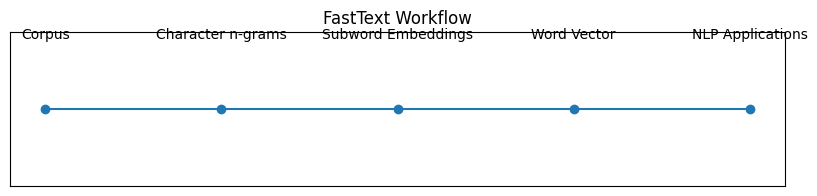

In [14]:
steps = [

    "Corpus",

    "Character n-grams",

    "Subword Embeddings",

    "Word Vector",

    "NLP Applications"

]

plt.figure(figsize=(10,2))

plt.plot(range(len(steps)),
         [1]*len(steps),
         marker="o")

for i, step in enumerate(steps):

    plt.text(i,1.05,step,ha="center")

plt.xticks([])
plt.yticks([])

plt.title("FastText Workflow")

plt.show()